In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [2]:
df = pd.read_csv('spread_locator_dataset.csv')
df

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


In [12]:
df.dropna

<bound method DataFrame.dropna of                            transaction_id customer_id  transaction_amount  \
0    e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1    11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2    82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3    f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4    8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   
..                                    ...         ...                 ...   
215  10c2a8f2-89d0-485c-bf8f-9508d32a02fc    CUST5563             4356.76   
216  5618814b-f7e2-424d-9617-9fc8d8643370    CUST8579             2025.53   
217  5636c9e7-9d54-4654-9c89-fdf31be87d96    CUST5092             2648.08   
218  6ba09450-a455-4983-bbad-3dad292cc839    CUST2235             2338.62   
219  c7d958bb-62b5-43a8-bfb9-30edc213fa85    CUST8260             3105.52   

    transaction_date  transaction_count r

In [13]:
df.duplicated

<bound method DataFrame.duplicated of                            transaction_id customer_id  transaction_amount  \
0    e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1    11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2    82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3    f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4    8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   
..                                    ...         ...                 ...   
215  10c2a8f2-89d0-485c-bf8f-9508d32a02fc    CUST5563             4356.76   
216  5618814b-f7e2-424d-9617-9fc8d8643370    CUST8579             2025.53   
217  5636c9e7-9d54-4654-9c89-fdf31be87d96    CUST5092             2648.08   
218  6ba09450-a455-4983-bbad-3dad292cc839    CUST2235             2338.62   
219  c7d958bb-62b5-43a8-bfb9-30edc213fa85    CUST8260             3105.52   

    transaction_date  transaction_cou

In [14]:
df.isnull

<bound method DataFrame.isnull of                            transaction_id customer_id  transaction_amount  \
0    e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1    11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2    82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3    f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4    8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   
..                                    ...         ...                 ...   
215  10c2a8f2-89d0-485c-bf8f-9508d32a02fc    CUST5563             4356.76   
216  5618814b-f7e2-424d-9617-9fc8d8643370    CUST8579             2025.53   
217  5636c9e7-9d54-4654-9c89-fdf31be87d96    CUST5092             2648.08   
218  6ba09450-a455-4983-bbad-3dad292cc839    CUST2235             2338.62   
219  c7d958bb-62b5-43a8-bfb9-30edc213fa85    CUST8260             3105.52   

    transaction_date  transaction_count r

In [3]:
# Convert date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [4]:
# ==============================
# 1. BERNOULLI & BINOMIAL
# ==============================

# Create binary variable (transaction happened or not)
df['transaction_flag'] = 1  # assuming each row = transaction

# Bernoulli (probability of transaction)
p = df['transaction_flag'].mean()
print("Bernoulli probability (p):", p)

# Weekly transaction count (Binomial idea)
weekly_counts = df.groupby(df['transaction_date'].dt.isocalendar().week).size()

n = weekly_counts.max()  # approx trials
p_binom = weekly_counts.mean() / n

print("Binomial approx -> n:", n, "p:", p_binom)

Bernoulli probability (p): 1.0
Binomial approx -> n: 56 p: 0.6547619047619048


Poisson λ (mean): 7.096774193548387


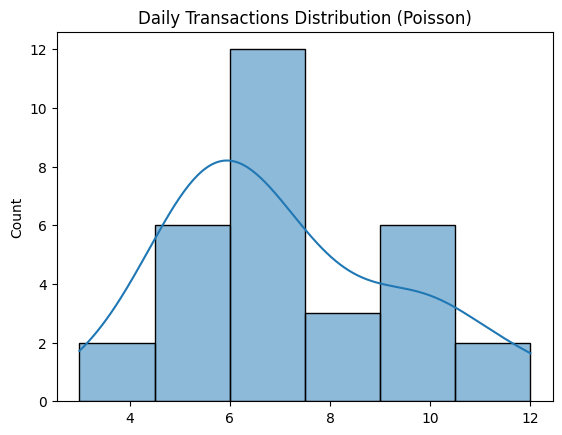

In [5]:
# ==============================
# 2. POISSON DISTRIBUTION
# ==============================

# Transactions per day
daily_counts = df.groupby(df['transaction_date'].dt.date).size()

lambda_poisson = daily_counts.mean()
print("Poisson λ (mean):", lambda_poisson)

# Plot
sns.histplot(daily_counts, kde=True)
plt.title("Daily Transactions Distribution (Poisson)")
plt.show()

In [6]:
# ==============================
# 3. LOG-NORMAL & POWER LAW
# ==============================

amounts = df['transaction_amount']

# Log-normal fit
shape, loc, scale = stats.lognorm.fit(amounts, floc=0)
print("Lognormal params:", shape, scale)

# Power law (Pareto)
pareto_shape, loc, scale = stats.pareto.fit(amounts)
print("Power law params:", pareto_shape)

Lognormal params: 0.4749178350151927 2983.1591334067753
Power law params: 107341796.39201096


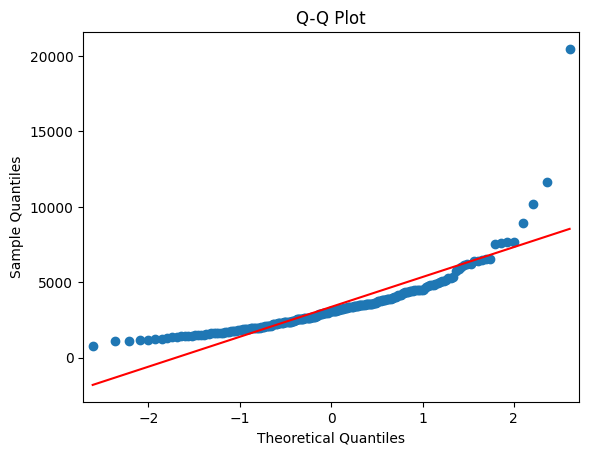

In [7]:
# ==============================
# 4. Q-Q PLOT (NORMALITY TEST)
# ==============================

sm.qqplot(amounts, line='s')
plt.title("Q-Q Plot")
plt.show()

Box-Cox Lambda: -0.18083390743966327


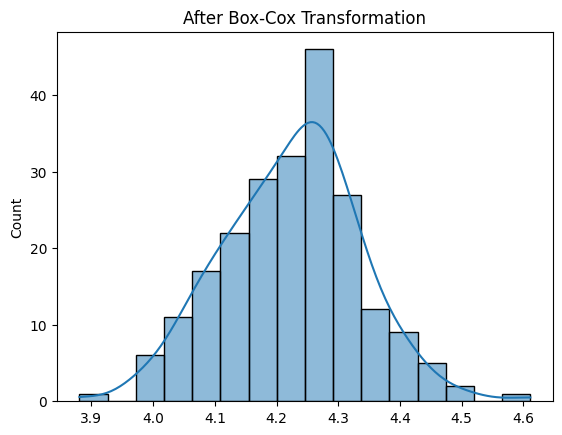

In [8]:
# ==============================
# 5. BOX-COX TRANSFORM
# ==============================

# Box-Cox requires positive data
amounts_positive = amounts[amounts > 0]

transformed_data, lambda_bc = stats.boxcox(amounts_positive)

print("Box-Cox Lambda:", lambda_bc)

# Plot after transform
sns.histplot(transformed_data, kde=True)
plt.title("After Box-Cox Transformation")
plt.show()

In [9]:
# ==============================
# 6. Z-SCORE & PROBABILITY
# ==============================

mean = amounts.mean()
std = amounts.std()

z_scores = (amounts - mean) / std
df['z_score'] = z_scores

# Probability of amount > 5000
prob = 1 - stats.norm.cdf(5000, loc=mean, scale=std)
print("P(X > 5000):", prob)

P(X > 5000): 0.20517209567554384


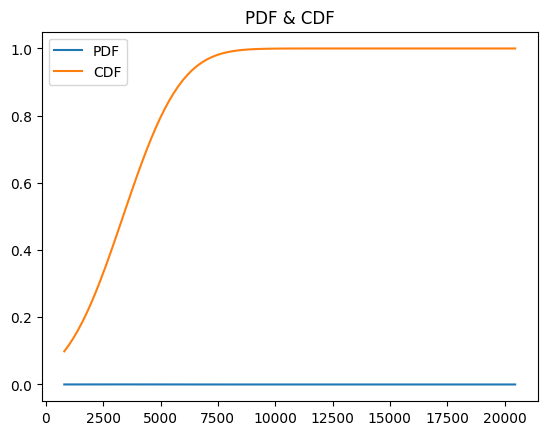

In [10]:
# ==============================
# 7. PDF & CDF
# ==============================

x = np.linspace(amounts.min(), amounts.max(), 100)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, pdf, label='PDF')
plt.plot(x, cdf, label='CDF')
plt.legend()
plt.title("PDF & CDF")
plt.show()

In [11]:
# ==============================
# 8. CONCLUSION LOGIC
# ==============================

print("\n===== INSIGHT =====")

print("1. If Q-Q plot deviates → data NOT normal")
print("2. If log transform improves → Log-normal is better")
print("3. Heavy tail → Power law fits")
print("4. Count data → Poisson works well")


===== INSIGHT =====
1. If Q-Q plot deviates → data NOT normal
2. If log transform improves → Log-normal is better
3. Heavy tail → Power law fits
4. Count data → Poisson works well
